# MPB LaTeX OCR - Local Checkpoint Toy Check

Use this notebook after downloading a trained run from Kaggle or another server. It checks that the acquired checkpoint, tokenizer, and config load locally, then evaluates the model on a small synthetic rendered-formula dataset.

This is a sanity check, not a final benchmark. The toy renderer is intentionally simple and may not match the real dataset style.

In [9]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image, ImageDraw


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "mpb_latex_ocr").exists():
            return candidate
    raise FileNotFoundError("Could not find mpb-latex-ocr project root from current notebook directory.")


PROJECT_DIR = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))
os.environ["PYTHONPATH"] = f"{SRC_DIR}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"

# Default layout after copying Kaggle artifacts into this repo.
RUN_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
TOKENIZER_PATH = RUN_DIR / "tokenizer.json"
RESOLVED_CONFIG_PATH = RUN_DIR / "resolved_config.json"

TOY_DIR = PROJECT_DIR / "data" / "toy_acquired_checkpoint_check"
TOY_MANIFEST = TOY_DIR / "manifest.csv"
CHECK_OUTPUT_DIR = RUN_DIR / "toy_check"
PREDICTIONS_PATH = CHECK_OUTPUT_DIR / "test_predictions.jsonl"
CDM_JSON_PATH = CHECK_OUTPUT_DIR / "cdm_predictions.json"

NUM_TOY_SAMPLES = 240
FORCE_REGENERATE_TOY = False
SPLIT = "test"
EVAL_BATCH_SIZE = 16
MAX_BATCHES = None  # Set to 1 or 2 for a very quick smoke run.
TOY_MAX_GENERATION_LENGTH = 96  # Toy formulas are short; this prevents long repeated junk.


def run_module(module: str, args: list[object], cwd: Path = PROJECT_DIR) -> None:
    command = [sys.executable, "-m", module, *[str(arg) for arg in args]]
    printable = " ".join(f'"{part}"' if " " in part else part for part in command)
    print(f"$ {printable}")
    subprocess.run(command, cwd=cwd, check=True, env=os.environ.copy())


print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_DIR:", RUN_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("TOKENIZER_PATH:", TOKENIZER_PATH)

import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PROJECT_DIR: C:\Projects\mpb-latex-ocr
RUN_DIR: C:\Projects\mpb-latex-ocr\outputs
CHECKPOINT_DIR: C:\Projects\mpb-latex-ocr\outputs\checkpoints
TOKENIZER_PATH: C:\Projects\mpb-latex-ocr\outputs\tokenizer.json
torch: 2.11.0+cu128
cuda available: True
device: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## Select The Downloaded Checkpoint

The selector prefers the lowest `val_ned=...` value in checkpoint filenames. If filenames do not contain `val_ned`, it falls back to the newest checkpoint file.

In [10]:
def checkpoint_val_ned(path: Path) -> float | None:
    match = re.search(r"val_ned=([0-9]+(?:\.[0-9]+)?)", path.name)
    return float(match.group(1)) if match else None


def pick_checkpoint(checkpoint_dir: Path) -> Path:
    checkpoints = sorted(checkpoint_dir.glob("*.ckpt"))
    if not checkpoints:
        raise FileNotFoundError(f"No .ckpt files found under {checkpoint_dir}")

    scored = [(checkpoint_val_ned(path), path) for path in checkpoints]
    with_metric = [(score, path) for score, path in scored if score is not None]
    if with_metric:
        return min(with_metric, key=lambda item: (item[0], item[1].name))[1]
    return max(checkpoints, key=lambda path: path.stat().st_mtime)


CHECKPOINT_PATH = pick_checkpoint(CHECKPOINT_DIR)

if not TOKENIZER_PATH.exists():
    raise FileNotFoundError(f"Missing tokenizer file: {TOKENIZER_PATH}")

if RESOLVED_CONFIG_PATH.exists():
    resolved_config = json.loads(RESOLVED_CONFIG_PATH.read_text(encoding="utf-8"))
else:
    resolved_config = {}

data_config = resolved_config.get("data", {})
generation_config = resolved_config.get("generation", {})
IMAGE_HEIGHT = int(data_config.get("image_height", 128))
IMAGE_WIDTH = int(data_config.get("image_width", 512))
MAX_LABEL_LENGTH = int(data_config.get("max_label_length", 256))
configured_max_generation_length = int(generation_config.get("max_length", MAX_LABEL_LENGTH))
MAX_GENERATION_LENGTH = min(configured_max_generation_length, TOY_MAX_GENERATION_LENGTH)
NUM_WORKERS = 0 if os.name == "nt" else int(data_config.get("num_workers", 2))

print("selected checkpoint:", CHECKPOINT_PATH)
print("val_ned from filename:", checkpoint_val_ned(CHECKPOINT_PATH))
print("image size:", IMAGE_WIDTH, "x", IMAGE_HEIGHT)
print("configured max generation length:", configured_max_generation_length)
print("toy max generation length:", MAX_GENERATION_LENGTH)
print("num workers:", NUM_WORKERS)

selected checkpoint: C:\Projects\mpb-latex-ocr\outputs\checkpoints\epoch=041-val_ned=0.0746.ckpt
val_ned from filename: 0.0746
image size: 512 x 128
configured max generation length: 256
toy max generation length: 96
num workers: 0


## Generate Toy Data

This creates simple rendered math images under `data/toy_acquired_checkpoint_check`. Set `FORCE_REGENERATE_TOY = True` in the first cell if you want a fresh toy set.

In [11]:
if FORCE_REGENERATE_TOY or not TOY_MANIFEST.exists():
    run_module(
        "mpb_latex_ocr.make_toy_data",
        [
            "--output-dir", TOY_DIR,
            "--num-samples", NUM_TOY_SAMPLES,
            "--image-width", IMAGE_WIDTH,
            "--image-height", IMAGE_HEIGHT,
        ],
    )
else:
    print("Using existing toy manifest:", TOY_MANIFEST)

print("toy manifest:", TOY_MANIFEST)
print("toy image count:", len(list((TOY_DIR / "images").glob("*.png"))))

Using existing toy manifest: C:\Projects\mpb-latex-ocr\data\toy_acquired_checkpoint_check\manifest.csv
toy manifest: C:\Projects\mpb-latex-ocr\data\toy_acquired_checkpoint_check\manifest.csv
toy image count: 240


## Check Tokenizer Coverage

If many toy tokens are missing from the downloaded tokenizer, toy exact-match scores will be less meaningful. The inference check can still catch broken checkpoints and badly formed outputs.

In [12]:
from mpb_latex_ocr.data.tokenizer import LatexTokenizer, tokenize_latex
from mpb_latex_ocr.make_toy_data import FORMULAS

tokenizer = LatexTokenizer.load(TOKENIZER_PATH)
missing_tokens = sorted(
    {
        token
        for formula in FORMULAS
        for token in tokenize_latex(formula)
        if token not in tokenizer.token_to_id
    }
)

print("vocab size:", len(tokenizer))
print("missing toy tokens:", missing_tokens if missing_tokens else "none")

vocab size: 543
missing toy tokens: ['\\lim', '\\sin', 'dx']


## Existing Downloaded Test Prediction Summary

If `outputs/test_predictions.jsonl` exists, this summarizes the real Kaggle/server evaluation you already downloaded. This is usually a better quality signal than the toy check because it matches the training data distribution.

In [13]:
EXISTING_PREDICTIONS_PATH = RUN_DIR / "test_predictions.jsonl"


def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def summarize_prediction_rows(prediction_rows: list[dict]) -> dict[str, float]:
    metric_keys = [
        "exact_match",
        "norm_edit_distance",
        "render_f1",
        "render_iou",
        "render_match",
        "prediction_rendered",
        "target_rendered",
    ]
    summary = {"num_samples": len(prediction_rows)}
    for key in metric_keys:
        if prediction_rows and key in prediction_rows[0]:
            summary[key] = sum(float(row.get(key, 0.0)) for row in prediction_rows) / len(prediction_rows)
    return summary


if EXISTING_PREDICTIONS_PATH.exists():
    existing_rows = load_jsonl(EXISTING_PREDICTIONS_PATH)
    print(json.dumps(summarize_prediction_rows(existing_rows), indent=2))
    try:
        import pandas as pd

        display(pd.DataFrame(existing_rows)[["target", "prediction", "exact_match", "norm_edit_distance", "render_f1", "prediction_rendered"]].head(10))
    except Exception:
        for row in existing_rows[:5]:
            print(row)
else:
    print("No downloaded test_predictions.jsonl found at", EXISTING_PREDICTIONS_PATH)


{
  "num_samples": 11916,
  "exact_match": 0.3945115810674723,
  "norm_edit_distance": 0.10075292168449941,
  "render_f1": 0.6315401162754198,
  "render_iou": 0.5968360730073918,
  "render_match": 0.5115810674723061,
  "prediction_rendered": 0.8847767707284323,
  "target_rendered": 0.935464921114468
}


,target,prediction,exact_match,norm_edit_distance,render_f1,prediction_rendered
0,z\longrightarrow\frac{az+b}{cz+d},z\longrightarrow\frac{az+b}{cz+d},1.0,0.000000,1.000000,1.0
1,{R_{B}}^{A}\=\ d{\phi_{B}}^{A}\+\{\phi_{B}}^{C...,R_{B}{}^{A}\;=\;d\phi_{B}{}^{A}\;+\;\phi_{B}{}...,0.0,0.194030,0.000000,1.0
2,\begin{array}{l}{1)\;\Gamma^{0}\Gamma(e^{||})\...,\begin{array}{l}{1)\;\Gamma^{0}\Gamma(e^{||})\...,0.0,0.194444,0.000000,0.0
3,S_{ij}(\theta)=\prod_{x=1}^{h}\prod_{y=1}^{H}\...,S_{ij}(\theta)=\prod_{x=1}^{h}\prod_{y=1}^{H}\...,0.0,0.091954,0.233217,1.0
4,D_{[\beta}^{i}W_{(\alpha_{1}]\ldots\alpha_{n})...,D_{[\beta}^{i}W_{(\alpha_{1}]\ldots\alpha_{n})...,1.0,0.000000,1.000000,1.0
5,\partial_{(--)}D_{(+)}W=-ie^{2W}\Psi_{L}^{(+)}...,"\partial_{(--)}D_{(+)}W=-ie^{2W}\Psi_{L}^{(+)},",0.0,0.113208,1.000000,1.0
6,"{\bf\check{R}}_{12}(\lambda)\,{\bf\check{R}}_{...","{\bf\tilde{R}}_{12}(\lambda)\,{\bf\tilde{R}}_{...",0.0,0.166667,0.195049,1.0
7,\{\begin{array}{l}{[-\frac{\hbar^{2}}{2}\sum_{...,\{\begin{array}{l}{[-\frac{\hbar^{2}}{2}\sum_{...,0.0,0.201493,0.000000,0.0
8,"V=\frac 1N\sum_{i=1}^{r}s_{i}\gamma_{i},","V=\frac{1}{N}\sum_{i=1}^{r}s_{i}\gamma_{i},",0.0,0.093023,0.000000,1.0
9,5u\frac{d^{2}R}{du^{2}}+10\frac{dR}{du}-\frac{...,5u\frac{d^{2}R}{du^{2}}+10\frac{dR}{du}-\frac{...,1.0,0.000000,1.000000,1.0


## Run The Toy Evaluation

This writes per-sample predictions and fast render-proxy metrics to `outputs/toy_check`. It also exports a CDM-style JSON file, but does not run official CDM.

In [14]:
CHECK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

eval_args = [
    "--checkpoint", CHECKPOINT_PATH,
    "--manifest", TOY_MANIFEST,
    "--image-root", TOY_DIR,
    "--tokenizer", TOKENIZER_PATH,
    "--split", SPLIT,
    "--batch-size", EVAL_BATCH_SIZE,
    "--num-workers", NUM_WORKERS,
    "--image-height", IMAGE_HEIGHT,
    "--image-width", IMAGE_WIDTH,
    "--max-label-length", MAX_LABEL_LENGTH,
    "--max-generation-length", MAX_GENERATION_LENGTH,
    "--render-metric",
    "--predictions-out", PREDICTIONS_PATH,
    "--cdm-json-out", CDM_JSON_PATH,
]

if MAX_BATCHES is not None:
    eval_args.extend(["--max-batches", MAX_BATCHES])

run_module("mpb_latex_ocr.evaluate", eval_args)
print("predictions:", PREDICTIONS_PATH)
print("cdm json:", CDM_JSON_PATH)

$ c:\Projects\mpb-latex-ocr\.venv\Scripts\python.exe -m mpb_latex_ocr.evaluate --checkpoint C:\Projects\mpb-latex-ocr\outputs\checkpoints\epoch=041-val_ned=0.0746.ckpt --manifest C:\Projects\mpb-latex-ocr\data\toy_acquired_checkpoint_check\manifest.csv --image-root C:\Projects\mpb-latex-ocr\data\toy_acquired_checkpoint_check --tokenizer C:\Projects\mpb-latex-ocr\outputs\tokenizer.json --split test --batch-size 16 --num-workers 0 --image-height 128 --image-width 512 --max-label-length 256 --max-generation-length 96 --render-metric --predictions-out C:\Projects\mpb-latex-ocr\outputs\toy_check\test_predictions.jsonl --cdm-json-out C:\Projects\mpb-latex-ocr\outputs\toy_check\cdm_predictions.json
predictions: C:\Projects\mpb-latex-ocr\outputs\toy_check\test_predictions.jsonl
cdm json: C:\Projects\mpb-latex-ocr\outputs\toy_check\cdm_predictions.json


## Read The Results

Look first at `prediction_render_success`, `render_f1_with_failures`, and a few decoded examples. Low toy exact match is not automatically fatal if the outputs are valid and visually close, because this model was trained on the Kaggle render style rather than this toy renderer.

In [15]:
rows = load_jsonl(PREDICTIONS_PATH)

def mean(key: str) -> float:
    return sum(float(row.get(key, 0.0)) for row in rows) / max(1, len(rows))


summary = {
    "num_samples": len(rows),
    "exact_match": mean("exact_match"),
    "norm_edit_distance": mean("norm_edit_distance"),
    "render_f1_with_failures": mean("render_f1"),
    "render_iou_with_failures": mean("render_iou"),
    "render_match": mean("render_match"),
    "prediction_render_success": mean("prediction_rendered"),
    "target_render_success": mean("target_rendered"),
    "avg_prediction_chars": sum(len(row.get("prediction", "")) for row in rows) / max(1, len(rows)),
}
print(json.dumps(summary, indent=2))
if summary["prediction_render_success"] < 0.5 or summary["avg_prediction_chars"] > 120:
    print("\nToy verdict: the acquired model is producing long or mostly non-renderable LaTeX on this toy distribution.")
    print("This does not automatically invalidate the real Kaggle run, but it means this checkpoint is not robust to the toy renderer.")

try:
    import pandas as pd

    preview_columns = [
        "sample_id",
        "target",
        "prediction",
        "exact_match",
        "norm_edit_distance",
        "render_f1",
        "prediction_rendered",
        "render_error",
    ]
    display(pd.DataFrame(rows)[preview_columns].head(20))
except Exception:
    for row in rows[:10]:
        print(row)

{
  "num_samples": 24,
  "exact_match": 0.0,
  "norm_edit_distance": 0.955906846460866,
  "render_f1_with_failures": 0.002695703854644252,
  "render_iou_with_failures": 0.0013700107874865157,
  "render_match": 0.0,
  "prediction_render_success": 0.08333333333333333,
  "target_render_success": 1.0,
  "avg_prediction_chars": 207.83333333333334
}

Toy verdict: the acquired model is producing long or mostly non-renderable LaTeX on this toy distribution.
This does not automatically invalidate the real Kaggle run, but it means this checkpoint is not robust to the toy renderer.


,sample_id,target,prediction,exact_match,norm_edit_distance,render_f1,prediction_rendered,render_error
0,216,\lim_{x\to 0}\frac{\sin x}{x}=1,\begin{array}{c}{\mathbf{j}{\mathbf{j}}{\mathb...,0.0,0.890625,0.000000,0.0,prediction render failed: \n\begin{array}{c}{\...
1,217,\sum_{i=1}^n i=\frac{n(n+1)}{2},{\bf\large{\large{\large{\large{\large{\large{...,0.0,0.931579,0.000000,0.0,prediction render failed: \n{\bf\large{\large{...
2,218,\lim_{x\to 0}\frac{\sin x}{x}=1,\begin{array}{c}{\mathbf{j}{\mathbf{j}}{\mathb...,0.0,0.890625,0.000000,0.0,prediction render failed: \n\begin{array}{c}{\...
3,219,\sqrt{x+1},\begin{array}{c}{\int}\\{\Phi_{\parallel}}\\{=...,0.0,0.976096,0.000000,0.0,prediction render failed: \n\begin{array}{c}{\...
4,220,\sum_{i=1}^n i=\frac{n(n+1)}{2},{\bf\large{\large{\large{\large{\large{\large{...,0.0,0.931579,0.000000,0.0,prediction render failed: \n{\bf\large{\large{...
5,221,\frac{a}{b}+c,{\bf\large g}\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\...,0.0,0.979275,0.000000,0.0,prediction render failed: \n{\bf\large g}\!\!\...
6,222,\frac{a}{b}+c,{\bf\large g}\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\...,0.0,0.979275,0.000000,0.0,prediction render failed: \n{\bf\large g}\!\!\...
7,223,\sqrt{x+1},\begin{array}{c}{\int}\\{\Phi_{\parallel}}\\{=...,0.0,0.976096,0.000000,0.0,prediction render failed: \n\begin{array}{c}{\...
8,224,e^{i\pi}+1=0,\Phi\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!\!...,0.0,0.989583,0.032348,1.0,None
9,225,\sqrt{x+1},\begin{array}{c}{\int}\\{\Phi_{\parallel}}\\{=...,0.0,0.976096,0.000000,0.0,prediction render failed: \n\begin{array}{c}{\...


## Visual Spot Check

Each row shows the input crop, the target render, and the prediction render. Rendering failures are shown as text placeholders.

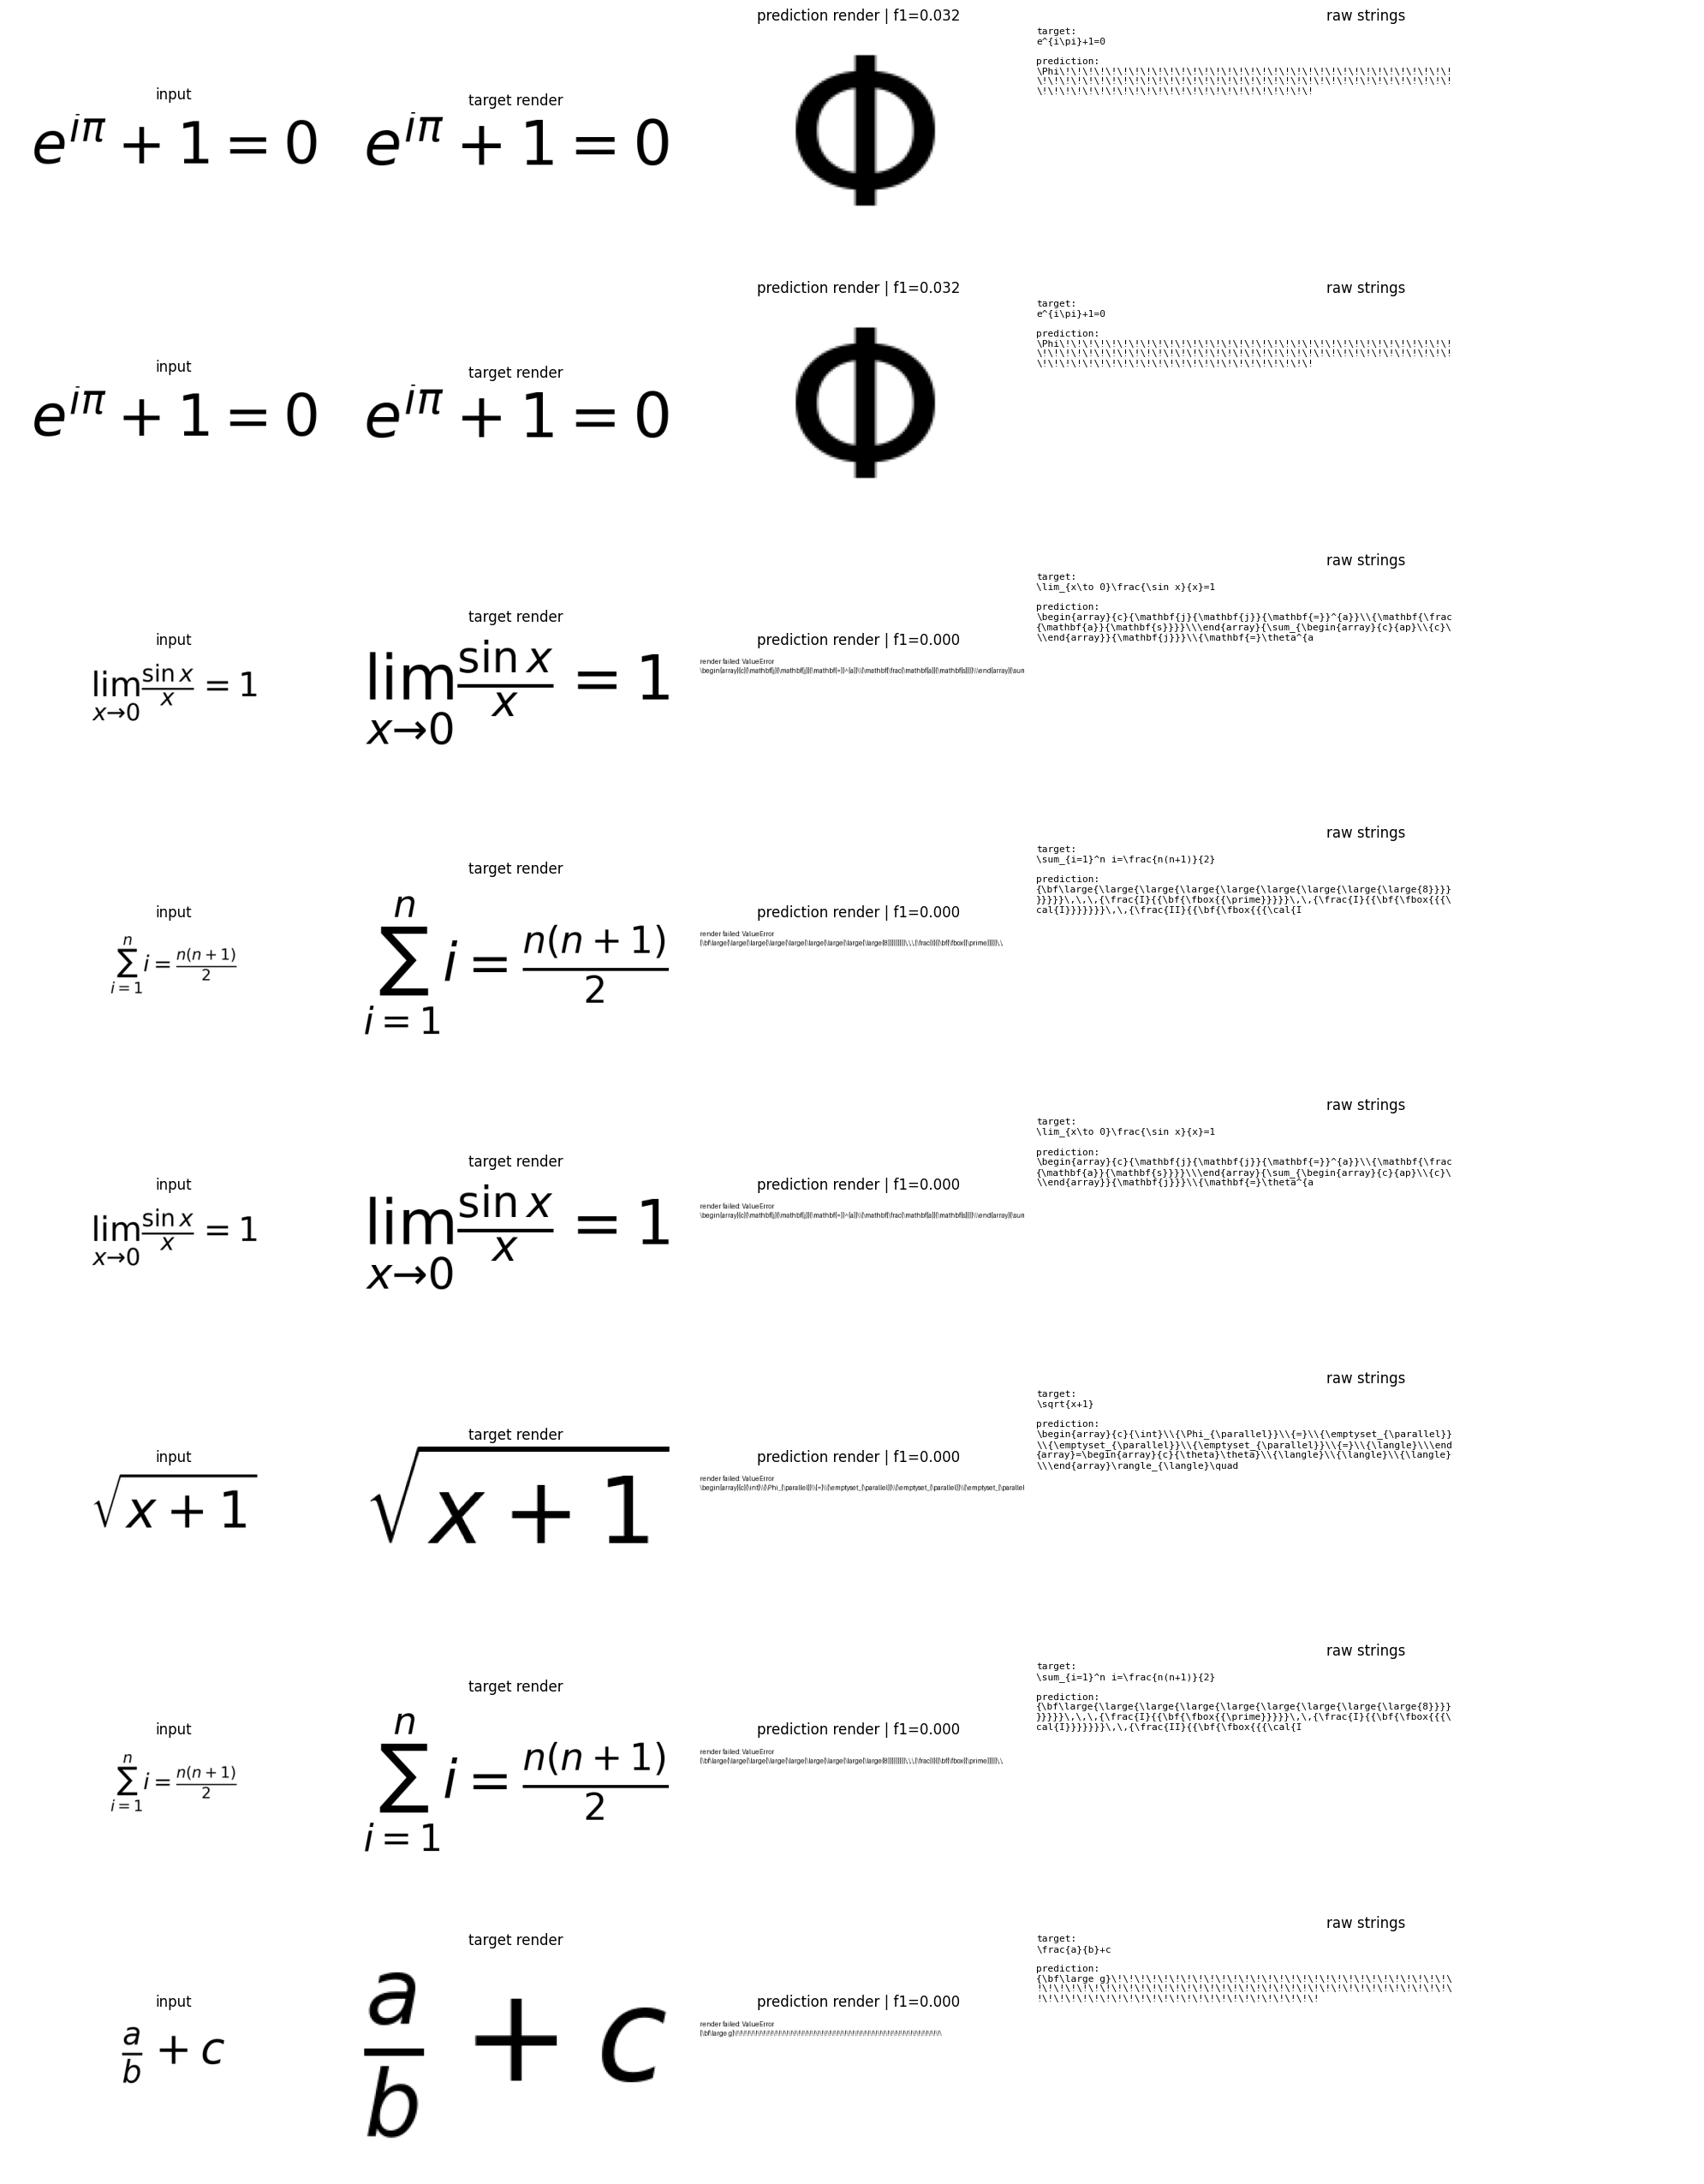

In [16]:
import textwrap

from mpb_latex_ocr.metrics.render import render_formula_image


def safe_formula_image(formula: str) -> Image.Image:
    try:
        return render_formula_image(formula)
    except Exception as exc:
        image = Image.new("L", (512, 128), color=255)
        draw = ImageDraw.Draw(image)
        draw.text((10, 10), f"render failed: {type(exc).__name__}\n{str(formula)[:120]}", fill=0)
        return image


def clipped_text(value: str, max_chars: int = 420) -> str:
    value = str(value)
    if len(value) > max_chars:
        value = value[:max_chars] + " ..."
    return "\n".join(textwrap.wrap(value, width=72, break_long_words=True))


sample_rows = sorted(rows, key=lambda row: float(row.get("render_f1", 0.0)), reverse=True)[: min(8, len(rows))]
fig, axes = plt.subplots(
    len(sample_rows),
    4,
    figsize=(20, 3.2 * max(1, len(sample_rows))),
    gridspec_kw={"width_ratios": [1.2, 1.2, 1.2, 2.4]},
)
if len(sample_rows) == 1:
    axes = [axes]

for row_axes, row in zip(axes, sample_rows, strict=True):
    input_image = Image.open(row["image_path"]).convert("L")
    target_image = safe_formula_image(row["target"])
    prediction_image = safe_formula_image(row["prediction"])

    for axis, image, title in [
        (row_axes[0], input_image, "input"),
        (row_axes[1], target_image, "target render"),
        (row_axes[2], prediction_image, f"prediction render | f1={float(row.get('render_f1', 0.0)):.3f}"),
    ]:
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title)
        axis.axis("off")

    row_axes[3].axis("off")
    row_axes[3].set_title("raw strings")
    row_axes[3].text(
        0,
        1,
        "target:\n" + clipped_text(row.get("target", ""), 180) + "\n\n" + "prediction:\n" + clipped_text(row.get("prediction", "")),
        va="top",
        ha="left",
        family="monospace",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## Interpretation

- If the checkpoint does not load, the copied `.ckpt`, `tokenizer.json`, or code version is mismatched.
- If predictions are empty or never render, inspect tokenizer coverage and the selected checkpoint.
- If toy metrics are bad but `outputs/test_predictions.jsonl` is good, the checkpoint is probably overfit to the real dataset render style and not robust to the toy renderer.
- After updating the repo, rerun evaluation on Kaggle/server so targets are read from the manifest text rather than decoded through the tokenizer.
- Keep `outputs/toy_check/test_predictions.jsonl` as the quick artifact to inspect when comparing downloaded checkpoints.